In [2]:
# By Linde Olde Olthof

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
import time

layer1 = 'normalmetal'
# choose vacuum or normalmetal

layer2 = 'chiral'
# choose px, py or chiral

###############################################################################
# Define parameters
###############################################################################
Nx1 = 30  # number of points in x-direction, in left superconductor
NxP = 30  # number of points in x-direction, in right superconductor
Nx = Nx1 + NxP
Ny = 50   # number of points in y-direction

T = 0.02  # temperature
beta = 1 / T
t = 1     # hopping parameter, should always be 1 for normalisation

# parameters material on the left
mu1 = 1.2

# parameters material on the right
muP = 1.8
V = 1.5   # nearest neighbour interaction

###############################################################################
# Initiate numerics for k-loop
###############################################################################
# Define a list of momenta for the summation over momentum
ky_list = np.linspace(np.pi / Ny, np.pi, Ny)

AbsTol = 1e-3
RelTol = 1e-1   # relative tolerance
maxItr = 500    # maximum number of iterations

# difference between current and previous pair amplitude
absdiff1 = 100
absdiff2 = 100
absdiff3 = 100
absdiff4 = 100
reldiff1 = 100
reldiff2 = 100
reldiff3 = 100
reldiff4 = 100

Itr = 0  # current iteration

# Reset while-loop conditions
c1 = True
c2 = True
c3 = True

# Initial values for order parameter
if layer2 == 'px':
    Fx_plus = 0.1 * np.concatenate((np.zeros(Nx1), np.ones(NxP - 1)))
    Fx_min = 0.1 * np.concatenate((np.zeros(Nx1), -np.ones(NxP - 1)))
    Fy_plus = np.zeros(Nx, dtype=complex)
    Fy_min = np.zeros(Nx, dtype=complex)
elif layer2 == 'py':
    Fx_plus = np.zeros(Nx - 1, dtype=complex)
    Fx_min = np.zeros(Nx - 1, dtype=complex)
    Fy_plus = 0.1 * np.concatenate((np.zeros(Nx1), 1j * np.ones(NxP)))
    Fy_min = 0.1 * np.concatenate((np.zeros(Nx1), -1j * np.ones(NxP)))
elif layer2 == 'chiral':
    Fx_plus = 0.1 * np.concatenate((np.zeros(Nx1), np.ones(NxP - 1)))
    Fx_min = 0.1 * np.concatenate((np.zeros(Nx1), -np.ones(NxP - 1)))
    Fy_plus = 0.1 * np.concatenate((np.zeros(Nx1), 1j * np.ones(NxP)))
    Fy_min = 0.1 * np.concatenate((np.zeros(Nx1), -1j * np.ones(NxP)))

###############################################################################
# Calculate order parameter profile iteratively
###############################################################################
start_time = time.time()

while c1 and c2 and c3:

    H0 = np.zeros((4 * Nx, 4 * Nx), dtype=complex)
    H1 = np.zeros((4 * Nx, 4 * Nx), dtype=complex)  # empty k-independent Hamiltonian
    H2 = np.zeros((4 * Nx, 4 * Nx), dtype=complex)  # empty k-dependent Hamiltonian

    ###########################################################################
    # Filling the k-independent Hamiltonian H1
    ###########################################################################
    # Chemical potential
    diag_vals_left = np.tile(np.array([-mu1, -mu1, mu1, mu1]), Nx1)
    diag_vals_right = np.tile(np.array([-muP, -muP, muP, muP]), NxP)

    for i in range(4 * Nx1):
        H1[i, i] = diag_vals_left[i]
    for i in range(4 * NxP):
        H1[4 * Nx1 + i, 4 * Nx1 + i] = diag_vals_right[i]

    if layer1 == 'vacuum':
        # Hopping vacuum
        hop_vac = np.zeros(4 * Nx1)
        hop_pwave = np.tile(np.array([-t, -t, t, t]), NxP - 1)
        hop_full = np.concatenate((hop_vac, hop_pwave))

        for i in range(4 * (Nx - 1)):
            H1[i, i + 4] = hop_full[i]   # Upper diagonal
            H1[i + 4, i] = hop_full[i]   # Lower diagonal

    elif layer1 == 'normalmetal':
        # Hopping normal metal
        hop_full = np.tile(np.array([-t, -t, t, t]), Nx - 1)

        for i in range(4 * (Nx - 1)):
            H1[i, i + 4] = hop_full[i]   # Upper diagonal
            H1[i + 4, i] = hop_full[i]   # Lower diagonal

    if layer2 in ['px', 'chiral']:
        # p-wave off-diagonal x-terms
        Fx1 = np.concatenate((np.zeros(Nx1 - 1), [V * Fx_min[Nx1 - 1] / 2], V * Fx_min[Nx1:]))
        Fx2 = np.concatenate((np.zeros(Nx1 - 1), [V * Fx_plus[Nx1 - 1] / 2], V * Fx_plus[Nx1:]))

        # Upper diagonal
        for n in range(Nx - 1):
            i = 4 * n
            H1[i,     i + 7] =  Fx2[n]   # Element (1,4)
            H1[i + 1, i + 6] = -Fx1[n]   # Element (2,3)
            H1[i + 2, i + 5] = -Fx2[n]   # Element (3,2)
            H1[i + 3, i + 4] =  Fx1[n]   # Element (4,1)

        # Lower diagonal
        for n in range(Nx - 1):
            i = 4 * n
            H1[i + 4, i + 3] =  Fx1[n]   # Element (1,4)
            H1[i + 5, i + 2] = -Fx2[n]   # Element (2,3)
            H1[i + 6, i + 1] = -Fx1[n]   # Element (3,2)
            H1[i + 7, i    ] =  Fx2[n]   # Element (4,1)

    ###########################################################################
    # Calculating the k = 0 terms
    ###########################################################################
    # dispersion
    if layer1 == 'vacuum':
        diag0 = np.concatenate((np.zeros(4 * Nx1), np.tile(np.array([-2 * t, -2 * t, 2 * t, 2 * t]), NxP)))
        for i in range(4 * Nx):
            H0[i, i] = diag0[i]
    elif layer1 == 'normalmetal':
        diag0 = np.tile(np.array([-2 * t, -2 * t, 2 * t, 2 * t]), Nx)
        for i in range(4 * Nx):
            H0[i, i] = diag0[i]

    if layer2 in ['py', 'chiral']:
        # Superconductor y-terms for p-wave
        Fy_14_P = V * (Fy_plus[Nx1:] + Fy_min[Nx1:])
        Fy_14 = np.concatenate((np.zeros(Nx1), Fy_14_P))
        Fy_23_P = -V * (Fy_plus[Nx1:] + Fy_min[Nx1:])
        Fy_23 = np.concatenate((np.zeros(Nx1), Fy_23_P))
        Fy_32 = Fy_23.conj()
        Fy_41 = Fy_14.conj()

        for n in range(Nx):
            i = 4 * n
            H0[i,     i + 3] = Fy_14[n]  # Element (1,4)
            H0[i + 1, i + 2] = Fy_23[n]  # Element (2,3)
            H0[i + 2, i + 1] = Fy_32[n]  # Element (3,2)
            H0[i + 3, i    ] = Fy_41[n]  # Element (4,1)

    # Diagonalise and extract eigenvectors
    eigval0, eigvec0 = eig(H0 + H1)
    u0 = eigvec0[0::4, :]
    v0 = eigvec0[1::4, :]
    w0 = eigvec0[2::4, :]
    x0 = eigvec0[3::4, :]

    # Fermi-Dirac distribution
    Energies0 = np.tile(eigval0.reshape(1, -1), (Nx, 1))
    f_E0 = 1 / (np.exp(beta * Energies0) + 1)
    pos_energy = Energies0 > 0  # filter positive energies only

    # Pair correlations individual terms
    Fx0_ux1 = u0[:-1, :] * np.conj(x0[1:, :]) * (1 - f_E0[:-1, :]) * pos_energy[:-1, :]
    Fx0_ux2 = u0[1:, :] * np.conj(x0[:-1, :]) * (1 - f_E0[1:, :]) * pos_energy[1:, :]
    Fx0_vw1 = v0[:-1, :] * np.conj(w0[1:, :]) * f_E0[1:, :] * pos_energy[1:, :]
    Fx0_vw2 = v0[1:, :] * np.conj(w0[:-1, :]) * f_E0[:-1, :] * pos_energy[:-1, :]
    Fy0_ux = u0 * np.conj(x0) * (1 - f_E0) * pos_energy
    Fy0_vw = v0 * np.conj(w0) * f_E0 * pos_energy

    # Calculate all the constant offsets
    # and initialise vectors using k=0 terms
    Fx_plus_new = np.sum(Fx0_ux1 + Fx0_vw2, axis=1) / Ny
    Fx_min_new = np.sum(Fx0_ux2 + Fx0_vw1, axis=1) / Ny
    K_y0 = np.sum(Fy0_ux + Fy0_vw, axis=1) / Ny
    Fy_plus_new = K_y0.copy()
    Fy_min_new = K_y0.copy()

    # Triplet symmetry
    FT_x_plus = np.sum(Fx0_ux1 - Fx0_ux2 + Fx0_vw2 - Fx0_vw1, axis=1) / (2 * Ny)
    FT_x_min = np.sum(Fx0_ux2 - Fx0_ux1 + Fx0_vw1 - Fx0_vw2, axis=1) / (2 * Ny)
    FT_y_plus = np.zeros(Nx, dtype=complex)
    FT_y_min = np.zeros(Nx, dtype=complex)

    for ky in ky_list:

        #######################################################################
        # Filling the k-dependent Hamiltonian H2 for single ky
        #######################################################################
        H2.fill(0)

        # Dispersion relation
        epsilon = -2 * t * np.cos(ky)
        if layer1 == 'vacuum':
            diag2 = np.concatenate((np.zeros(4 * Nx1), np.tile(np.array([epsilon, epsilon, -epsilon, -epsilon]), NxP)))
            for i in range(4 * Nx):
                H2[i, i] = diag2[i]
        elif layer1 == 'normalmetal':
            diag2 = np.tile(np.array([epsilon, epsilon, -epsilon, -epsilon]), Nx)
            for i in range(4 * Nx):
                H2[i, i] = diag2[i]

        if layer2 in ['py', 'chiral']:
            # Superconductor block diagonal y-terms for p-wave
            Fy_14_P = V * (Fy_plus[Nx1:] * np.exp(-1j * ky) + Fy_min[Nx1:] * np.exp(1j * ky))
            Fy_14 = np.concatenate((np.zeros(Nx1), Fy_14_P))
            Fy_23_P = -V * (Fy_plus[Nx1:] * np.exp(1j * ky) + Fy_min[Nx1:] * np.exp(-1j * ky))
            Fy_23 = np.concatenate((np.zeros(Nx1), Fy_23_P))
            Fy_32 = Fy_23.conj()
            Fy_41 = Fy_14.conj()

            for n in range(Nx):
                i = 4 * n
                H2[i,     i + 3] = Fy_14[n]  # Element (1,4)
                H2[i + 1, i + 2] = Fy_23[n]  # Element (2,3)
                H2[i + 2, i + 1] = Fy_32[n]  # Element (3,2)
                H2[i + 3, i    ] = Fy_41[n]  # Element (4,1)

        #######################################################################
        # Construct full Hamiltonian and diagonalise it
        #######################################################################
        H = H1 + H2
        eigval, eigvec = eig(H)  # eigenvectors and eigenvalues

        # extract components eigenvectors from matrix
        u = eigvec[0::4, :]
        v = eigvec[1::4, :]
        w = eigvec[2::4, :]
        x = eigvec[3::4, :]

        #######################################################################
        # Calculate Delta for a single ky
        #######################################################################
        # Fermi-Dirac distribution
        Energies = np.tile(eigval.reshape(1, -1), (Nx, 1))
        f_E = 1 / (np.exp(beta * Energies) + 1)

        # Pair correlations individual terms
        Fx_ux1 = (u[:-1, :] * np.conj(x[1:, :]) * (1 - f_E[:-1, :])).T
        Fx_ux2 = (u[1:, :] * np.conj(x[:-1, :]) * (1 - f_E[1:, :])).T
        Fx_vw1 = (v[:-1, :] * np.conj(w[1:, :]) * f_E[1:, :]).T
        Fx_vw2 = (v[1:, :] * np.conj(w[:-1, :]) * f_E[:-1, :]).T
        Fy_ux = (u * np.conj(x) * (1 - f_E)).T
        Fy_vw = (v * np.conj(w) * f_E).T

        # Constructing Fx+- and Fy+-
        Fx_plus_new = Fx_plus_new + np.sum(Fx_ux1 + Fx_vw2, axis=0) / Ny
        Fx_min_new = Fx_min_new + np.sum(Fx_ux2 + Fx_vw1, axis=0) / Ny
        Fy_plus_new = Fy_plus_new + np.sum(Fy_ux * np.exp(1j * ky) + Fy_vw * np.exp(-1j * ky), axis=0) / Ny
        Fy_min_new = Fy_min_new + np.sum(Fy_ux * np.exp(-1j * ky) + Fy_vw * np.exp(1j * ky), axis=0) / Ny

        # Triplet component
        FT_x_plus = FT_x_plus + np.sum(Fx_ux1 - Fx_ux2 + Fx_vw2 - Fx_vw1, axis=0) / (2 * Ny)
        FT_x_min = FT_x_min + np.sum(Fx_ux2 - Fx_ux1 + Fx_vw1 - Fx_vw2, axis=0) / (2 * Ny)
        FT_y_plus = FT_y_plus + 1j * np.sum(Fy_ux - Fy_vw, axis=0) * np.sin(ky) / Ny
        FT_y_min = FT_y_min - 1j * np.sum(Fy_ux - Fy_vw, axis=0) * np.sin(ky) / Ny

    # end ky-loop

    # Filtering out s, d, px and py wave
    F_px = (np.concatenate(([0], FT_x_plus)) - np.concatenate((FT_x_min, [0]))) / 2
    F_py = (FT_y_plus - FT_y_min) / 2

    ###########################################################################
    # Iterative calculation
    ###########################################################################
    # Calculate the absolute differences (for AbsTol)
    absdiff1 = np.linalg.norm(Fx_plus_new[Nx1:] - Fx_plus[Nx1:])
    absdiff2 = np.linalg.norm(Fx_min_new[Nx1:] - Fx_min[Nx1:])
    absdiff3 = np.linalg.norm(Fy_plus_new[Nx1:] - Fy_plus[Nx1:])
    absdiff4 = np.linalg.norm(Fy_min_new[Nx1:] - Fy_min[Nx1:])

    # Calculate the relative differences (for RelTol)
    reldiff1 = np.linalg.norm((Fx_plus_new[Nx1:] - Fx_plus[Nx1:]) / Fx_plus[Nx1:])
    reldiff2 = np.linalg.norm((Fx_min_new[Nx1:] - Fx_min[Nx1:]) / Fx_min[Nx1:])
    reldiff3 = np.linalg.norm((Fy_plus_new[Nx1:] - Fy_plus[Nx1:]) / Fy_plus[Nx1:])
    reldiff4 = np.linalg.norm((Fy_min_new[Nx1:] - Fy_min[Nx1:]) / Fy_min[Nx1:])

    Fx_plus = Fx_plus_new.copy()
    Fx_min = Fx_min_new.copy()
    Fy_plus = Fy_plus_new.copy()
    Fy_min = Fy_min_new.copy()
    Itr += 1

    if Itr == maxItr:
        print('Warning: Maximum number of iterations reached')

    # Conditions for convergence
    # Absolute tolerance s-wave
    c1 = (absdiff1 > AbsTol) or (absdiff2 > AbsTol) or (absdiff3 > AbsTol) or (absdiff4 > AbsTol)
    # Relative tolerance
    c2 = (reldiff1 > RelTol) or (reldiff2 > RelTol) or (reldiff3 > RelTol) or (reldiff4 > RelTol)
    # Maximum number of iterations reached
    c3 = Itr < maxItr

# end while-loop

print(f"Elapsed time: {time.time() - start_time:.6f} s")

Elapsed time: 20.248992 s


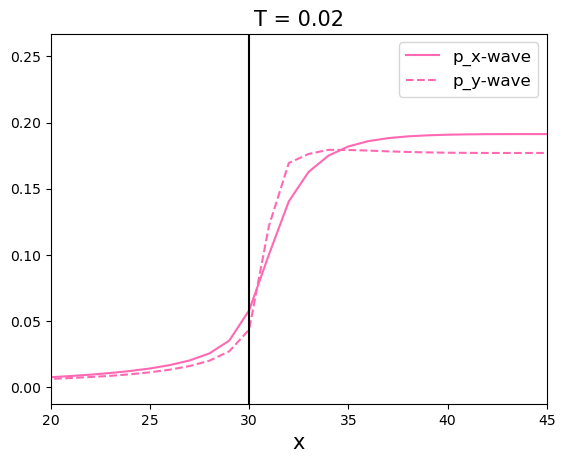

In [4]:
###############################################################################
# Plot
###############################################################################
# Define colours in RGB
forest = np.array([11, 102, 35]) / 255
color1 = np.array([0.3010, 0.7450, 0.9330])
color2 = np.array([255, 105, 180]) / 255
color3 = np.array([102, 205, 170]) / 255

plt.figure()
plt.plot(np.arange(1, Nx + 1), np.abs(F_px), color=color2)
plt.plot(np.arange(1, Nx + 1), np.abs(F_py), '--', color=color2)
plt.axvline(Nx1, color='k')
plt.xlabel('x', fontsize=15)
plt.title(f'T = {T}', fontsize=15)
plt.xlim([20, 45])
plt.legend(['p_x-wave', 'p_y-wave'], fontsize=12, loc='best')
plt.show()